# Internacoes x Qualidade do ar

Este notebook integra e analisa **internações por doenças respiratórias (SUS)** e **condições de qualidade do ar/meteorologia (DataRio)** no município do **Rio de Janeiro**, com o objetivo de **entender relações e preparar features** para prever:
- **`internacoes_d1`** (D+1) e **`internacoes_d7`** (D+7).

**O que é feito aqui (resumo):**
- Unificação das bases por **data** e criação dos **alvos** (`internacoes_d1`, `internacoes_d7`).
- Análises de correlação (ACF/PACF, CCF por lags), **médias móveis** (MM3…MM150) e **correlação rolante** (janela anual).
- **Estudo de eventos** (picos de poluentes via MM7) e **comparação visual** alvo × poluentes (z-score, séries semanais).
- Seleção de **janelas e defasagens candidatas** sem vazamento (sempre info ≤ _t_).


## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf as pacf_vals_fn
import seaborn as sns

## Unificação dos datasets (Internações × Ambiente)

**Objetivo:** juntar a série diária de **internações respiratórias** ao dataset diário de **variáveis ambientais** do Rio de Janeiro.

In [13]:
import numpy as np
import pandas as pd

url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTER_DR_RJ_SEAZONALITY.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
      .sort_values("data_dia")
      .reset_index(drop=True)
)

df_unificado.drop(columns=["ano", "mes", "dia"], inplace=True, errors="ignore")

print("Dimensões do unificado:", df_unificado.shape)
print("Intervalo de datas:", df_unificado["data_dia"].min(), "→", df_unificado["data_dia"].max())
print("\nColunas:", df_unificado.columns.tolist())
print("\nAmostra:")
display(df_unificado.head())
print("\nTipos de dados:")
print(df_unificado.dtypes)


Dimensões do unificado: (4748, 40)
Intervalo de datas: 2012-01-01 → 2024-12-30

Colunas: ['data_dia', 'chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'temp_min', 'temp_max', 'AQI', 'Qualidade_do_Ar', 'y', 'year', 'month', 'dow', 'doy', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_7', 'roll7_mean', 'roll7_std', 'roll14_mean', 'roll14_std', 'roll30_mean', 'roll30_std', 'stl_trend', 'stl_season']

Amostra:


,data_dia,chuva,temp,ur,co,no,no2,nox,so2,o3,...,y_lag_3,y_lag_7,roll7_mean,roll7_std,roll14_mean,roll14_std,roll30_mean,roll30_std,stl_trend,stl_season
0,2012-01-01,0.849992,25.835,92.165,0.215703,1.256189,4.184802,2.770516,1.567692,6.469835,...,NaN,NaN,507.000000,0.000000,507.000000,0.000000,507.000000,0.000000,645.896962,-197.197248
1,2012-01-02,0.891094,22.836,95.589,0.181572,1.884591,4.419030,3.019050,1.189413,6.013862,...,NaN,NaN,617.500000,156.270599,617.500000,156.270599,617.500000,156.270599,645.554593,-34.355772
2,2012-01-03,0.024357,24.948,76.139,0.165267,2.021231,4.512331,3.108324,2.004412,5.246714,...,NaN,NaN,554.666667,155.094595,554.666667,155.094595,554.666667,155.094595,645.212035,-71.854513
3,2012-01-04,0.047493,26.006,72.904,0.170964,2.175012,5.096621,3.324094,1.736737,6.754888,...,507.0,NaN,520.000000,144.372204,520.000000,144.372204,520.000000,144.372204,644.869285,-144.550309
4,2012-01-05,-0.000000,26.498,75.514,0.169471,2.007440,4.843477,3.181217,1.715770,7.889395,...,728.0,NaN,496.600000,135.537080,496.600000,135.537080,496.600000,135.537080,644.526341,-173.562390



Tipos de dados:
data_dia            object
chuva              float64
temp               float64
ur                 float64
co                 float64
no                 float64
no2                float64
nox                float64
so2                float64
o3                 float64
pm10               float64
pm2_5              float64
temp_min           float64
temp_max           float64
AQI                float64
Qualidade_do_Ar    float64
y                    int64
year                 int64
month                int64
dow                  int64
doy                  int64
is_weekend           int64
dow_sin            float64
dow_cos            float64
month_sin          float64
month_cos          float64
doy_sin            float64
doy_cos            float64
y_lag_1            float64
y_lag_2            float64
y_lag_3            float64
y_lag_7            float64
roll7_mean         float64
roll7_std          float64
roll14_mean        float64
roll14_std         float64
roll30_mean

In [5]:
project_root = Path().resolve().parents[1]  
output_dir = project_root / "data" 
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "INTERNACOES_x_QUALIAR_NEW.csv"
df_unificado.to_csv(output_csv_path, index=False, encoding="utf-8")

c:\Users\jhter\OneDrive - cefet-rj.br\qualiar\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


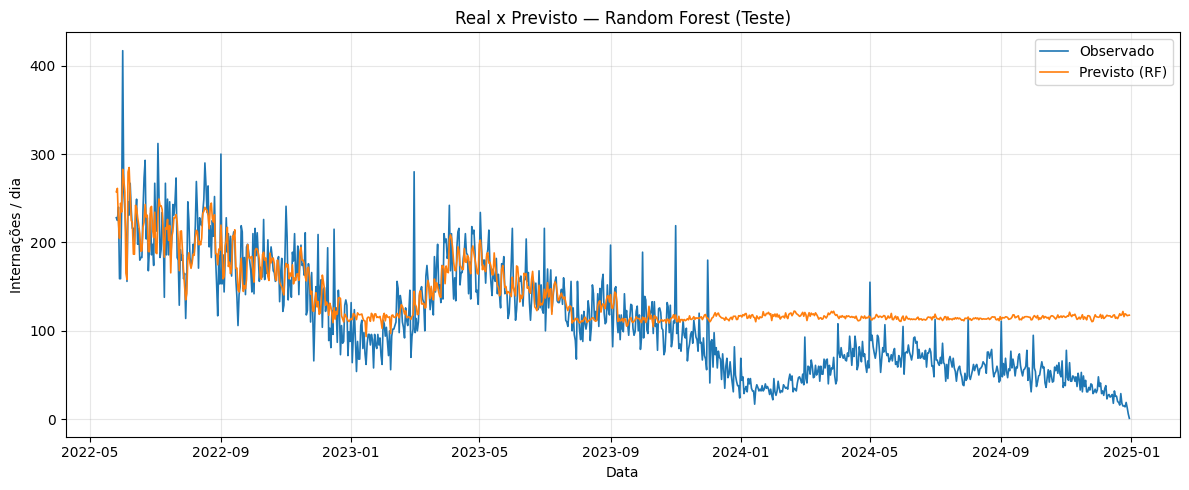

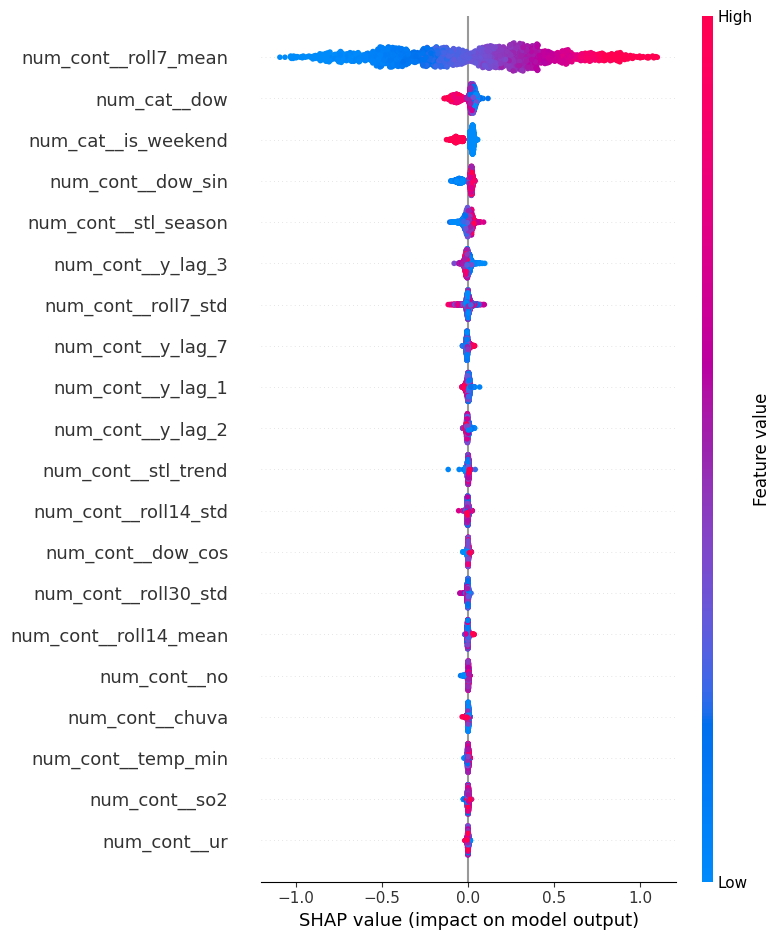

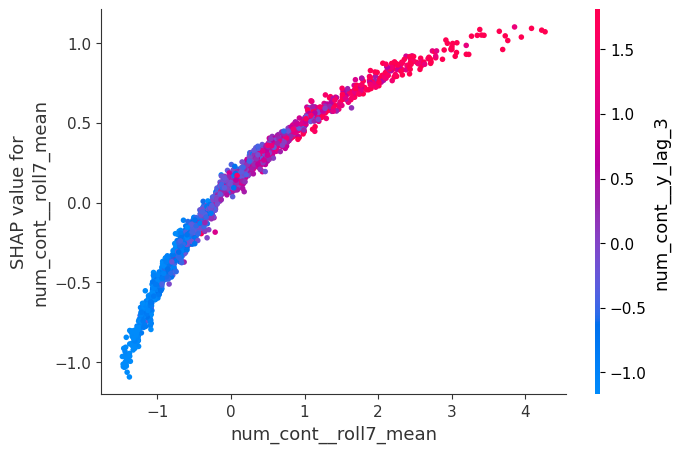

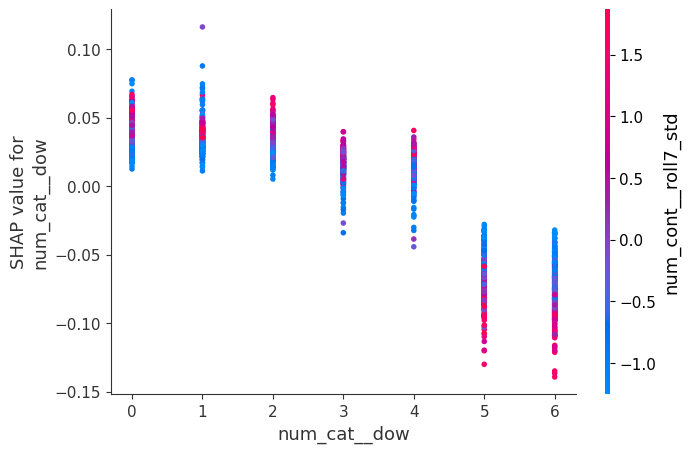

Treino: {'MAE': 18.72926637707648, 'MAPE': np.float64(5.779415793862333), 'RMSE': np.float64(27.75261178724922), 'R2': 0.9765909745227687}
Teste : {'MAE': 37.46552391236377, 'MAPE': np.float64(83.3986074135675), 'RMSE': np.float64(46.37808023086651), 'R2': 0.4484075927306024}


In [15]:
# -*- coding: utf-8 -*-
"""
Random Forest para prever internações diárias com:
- Log-transform no alvo (e inversão ao final)
- Normalização apenas de colunas numéricas CONTÍNUAS (não normaliza numéricas categóricas)
- Split temporal (hold-out)
- Métricas: MAE, MAPE, RMSE, R²
- Gráfico Real vs. Previsto
- Interpretação com SHAP
"""
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap


# =========================================================
# 0) SELEÇÃO DE COLUNAS E PREPARO
# =========================================================

def prepare_dataframe(df: pd.DataFrame, date_col: str = "data_dia") -> pd.DataFrame:
    """
    Garante tipos corretos, ordena por data e define o índice temporal.
    Também remove linhas com y ausente.
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.sort_values(date_col).set_index(date_col)
    data = data[~data["y"].isna()]
    return data


def define_feature_sets(df: pd.DataFrame) -> dict:
    """
    Define os conjuntos de colunas a usar no pré-processamento.
    - numeric_categorical: numéricas que representam categorias (NÃO normalizar)
      year, month, dow, doy, is_weekend
    - categorical: variáveis string (p.ex. Qualidade_do_Ar) -> one-hot
    - numeric_continuous: todas as demais numéricas contínuas (serão normalizadas)
    """
    all_cols = df.columns.tolist()

    target = "y"
    drop_cols = [target]  # alvo e/ou colunas que você não quer como preditor
    if "data_dia" in all_cols:
        drop_cols.append("data_dia")

    # numéricas categóricas (não normalizar)
    numeric_categorical = [c for c in ["year","month","dow","doy","is_weekend"] if c in all_cols]

    # categóricas string
    categorical = [c for c in ["Qualidade_do_Ar"] if c in all_cols]

    # todas numéricas
    numeric_all = df.drop(columns=drop_cols + categorical, errors="ignore").select_dtypes(include=[np.number]).columns.tolist()

    # contínuas = numéricas menos as categóricas
    numeric_continuous = [c for c in numeric_all if c not in numeric_categorical]

    return {
        "target": target,
        "numeric_categorical": numeric_categorical,
        "categorical": categorical,
        "numeric_continuous": numeric_continuous
    }


# =========================================================
# 1) SPLIT TEMPORAL
# =========================================================

def temporal_train_test_split(df: pd.DataFrame, test_size: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Faz split temporal preservando a ordem:
    - Últimos 'test_size' % dos dados vão para TESTE.
    Retorna (train_df, test_df).
    """
    n = len(df)
    cut = int(np.floor((1 - test_size) * n))
    train_df = df.iloc[:cut].copy()
    test_df  = df.iloc[cut:].copy()
    return train_df, test_df


# =========================================================
# 2) PIPELINE DE PRÉ-PROCESSAMENTO
# =========================================================

def build_preprocessor(column_sets: dict) -> ColumnTransformer:
    """
    Cria um ColumnTransformer:
    - numeric_continuous: Imputer(median) + StandardScaler
    - numeric_categorical: Imputer(median) + (passthrough, sem normalizar)
    - categorical: Imputer(most_frequent) + OneHotEncoder
    """
    num_cont = column_sets["numeric_continuous"]
    num_cat  = column_sets["numeric_categorical"]
    cat_cols = column_sets["categorical"]

    numeric_cont_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])

    numeric_cat_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))  # passa valores tal como estão
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num_cont", numeric_cont_pipeline, num_cont),
            ("num_cat",  numeric_cat_pipeline,  num_cat),
            ("cat",      categorical_pipeline,  cat_cols),
        ],
        remainder="drop"
    )
    return pre


# =========================================================
# 3) TREINAMENTO COM LOG-TRANSFORM NO ALVO
# =========================================================

def train_random_forest_with_log(
    train_df: pd.DataFrame,
    preprocessor: ColumnTransformer,
    column_sets: dict,
    rf_params: dict | None = None,
    random_state: int = 42
) -> tuple[Pipeline, np.ndarray, np.ndarray]:
    """
    Aplica log1p no alvo do TREINO, treina um Pipeline (preprocessador + RandomForestRegressor)
    e retorna (pipeline_treinado, y_log_train, y_train_original).

    rf_params padrão (robustez leve) se não informado.
    """
    y_col = column_sets["target"]
    X_cols = column_sets["numeric_continuous"] + column_sets["numeric_categorical"] + column_sets["categorical"]

    X_train = train_df[X_cols]
    y_train = train_df[y_col].values.astype(float)
    y_train_log = np.log1p(y_train)

    if rf_params is None:
        rf_params = dict(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=random_state
        )

    model = RandomForestRegressor(**rf_params)
    pipe = Pipeline(steps=[
        ("pre", preprocessor),
        ("rf", model)
    ])

    pipe.fit(X_train, y_train_log)
    return pipe, y_train_log, y_train


# =========================================================
# 4) PREDIÇÃO (INVERTE LOG) E MÉTRICAS
# =========================================================

def safe_mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    MAPE robusto: ignora pontos com y_true == 0 para evitar divisão por zero.
    Retorna em %.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0


def evaluate_model(pipe: Pipeline, df: pd.DataFrame, column_sets: dict) -> dict:
    """
    Faz previsão sobre df e calcula MAE, MAPE, RMSE e R² **no espaço original** (inverte o log).
    Retorna dict com métricas e um DataFrame com observado vs. previsto.
    """
    y_col = column_sets["target"]
    X_cols = column_sets["numeric_continuous"] + column_sets["numeric_categorical"] + column_sets["categorical"]

    X = df[X_cols]
    y_true = df[y_col].values.astype(float)

    y_pred_log = pipe.predict(X)
    y_pred = np.expm1(y_pred_log)  # volta do log

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = safe_mape(y_true, y_pred)

    results_df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    }, index=df.index)

    return {"MAE": mae, "MAPE": mape, "RMSE": rmse, "R2": r2, "pred_df": results_df}


# =========================================================
# 5) PLOT REAL vs. PREVISTO
# =========================================================

def plot_actual_vs_pred(pred_df: pd.DataFrame, title: str = "Real x Previsto (escala original)") -> None:
    """
    Gráfico de linha comparando observado e previsto ao longo do tempo.
    """
    plt.figure(figsize=(12,5))
    plt.plot(pred_df.index, pred_df["y_true"], label="Observado", lw=1.2)
    plt.plot(pred_df.index, pred_df["y_pred"], label="Previsto (RF)", lw=1.2)
    plt.title(title)
    plt.xlabel("Data")
    plt.ylabel("Internações / dia")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 6) SHAP (INTERPRETABILIDADE)
# =========================================================

def shap_analysis(pipe: Pipeline, train_df: pd.DataFrame, column_sets: dict, sample: int = 2000) -> None:
    """
    Aplica SHAP (TreeExplainer) ao RandomForest:
    - Extrai matriz transformada do pré-processador para o TREINO;
    - Obtém nomes de features pós-transformação (inclui dummies);
    - Plota summary plot e dependence plot para as 2 features mais influentes.

    Observação: SHAP trabalha no espaço **log** (porque o modelo foi treinado em y_log).
    """
    rf = pipe.named_steps["rf"]
    pre = pipe.named_steps["pre"]

    X_cols = column_sets["numeric_continuous"] + column_sets["numeric_categorical"] + column_sets["categorical"]
    X_train = train_df[X_cols]

    # transforma com o preprocessor
    Xtr = pre.transform(X_train)
    # nomes das colunas (pós-transform)
    try:
        feature_names = pre.get_feature_names_out().tolist()
    except Exception:
        feature_names = [f"f{i}" for i in range(Xtr.shape[1])]

    # amostra para agilizar
    if sample is not None and Xtr.shape[0] > sample:
        idx = np.random.RandomState(42).choice(Xtr.shape[0], size=sample, replace=False)
        X_sample = Xtr[idx]
    else:
        X_sample = Xtr

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot (importância global)
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=True)

    # Dependence para as 2 principais
    # Identifica as top-2 por |mean shap|
    mean_abs = np.mean(np.abs(shap_values), axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:2]
    for i in top_idx:
        shap.dependence_plot(i, shap_values, X_sample, feature_names=feature_names, show=True)


# =========================================================
# 7) PIPELINE PRINCIPAL
# =========================================================

def run_pipeline_rf(df_unificado: pd.DataFrame, test_size: float = 0.2) -> dict:
    """
    Executa todo o fluxo:
    - Preparo do DataFrame e seleção de colunas;
    - Split temporal train/test;
    - Pré-processamento (normalização apenas em contínuas; one-hot em categóricas);
    - Treino do RandomForest em y_log;
    - Avaliação em train e test (métricas na escala original);
    - Gráfico Real x Previsto (teste);
    - SHAP (interpretação no treino).
    Retorna dicionário com métricas e objetos úteis.
    """
    data = prepare_dataframe(df_unificado, date_col="data_dia")
    colsets = define_feature_sets(data)

    train_df, test_df = temporal_train_test_split(data, test_size=test_size)
    pre = build_preprocessor(colsets)
    pipe, ylog_train, ytrain = train_random_forest_with_log(train_df, pre, colsets, rf_params=None, random_state=42)

    # Métricas
    train_metrics = evaluate_model(pipe, train_df, colsets)
    test_metrics  = evaluate_model(pipe,  test_df,  colsets)

    # Plota Real x Previsto (teste)
    plot_actual_vs_pred(test_metrics["pred_df"], title="Real x Previsto — Random Forest (Teste)")

    # SHAP no treino
    shap_analysis(pipe, train_df, colsets, sample=2000)

    return {
        "pipeline": pipe,
        "column_sets": colsets,
        "train_metrics": {k:v for k,v in train_metrics.items() if k!="pred_df"},
        "test_metrics":  {k:v for k,v in test_metrics.items() if k!="pred_df"},
        "train_pred_df": train_metrics["pred_df"],
        "test_pred_df":  test_metrics["pred_df"],
    }


# ============================
# Exemplo de uso:
results = run_pipeline_rf(df_unificado, test_size=0.2)
print("Treino:", results["train_metrics"])
print("Teste :", results["test_metrics"])


## Análise de Correlação

### PACF das internações diárias

Objetivo: visualizar a **dependência temporal parcial** da série `num_internacoes`.  
Observação: o PACF é mais informativo em séries **estacionárias**; se houver tendência/sazonalidade, considere usar a versão **diferenciada** (exemplo comentado no código).


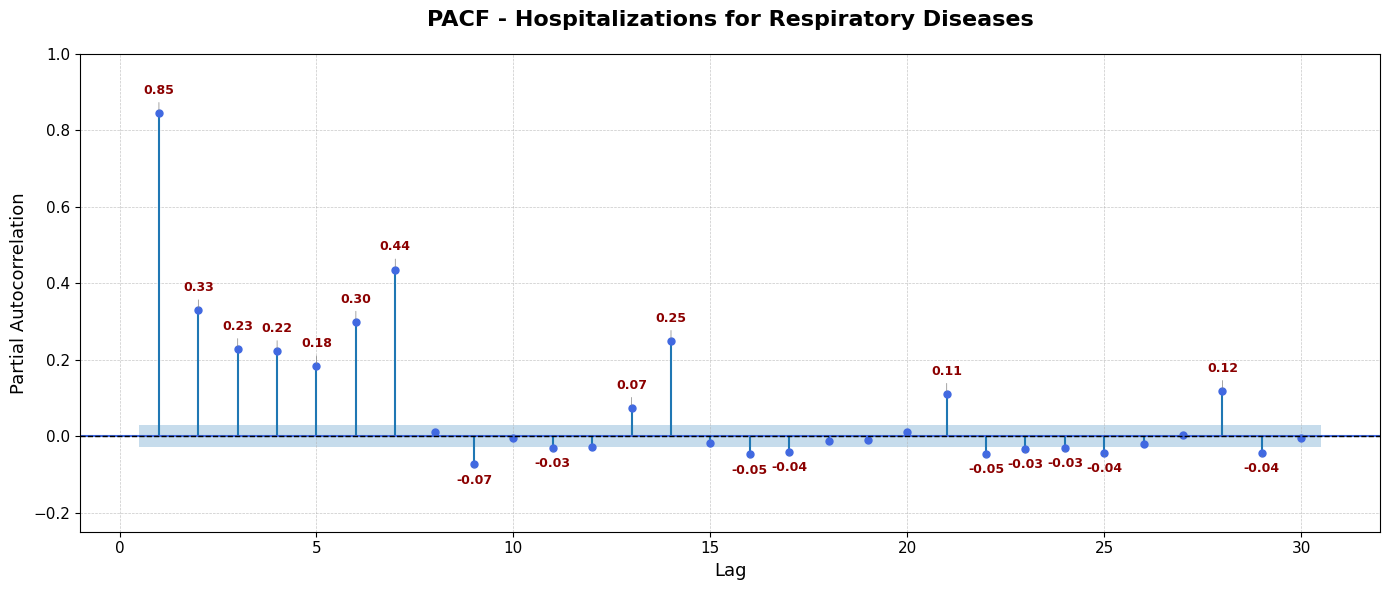

In [7]:
df_ = df_unificado.copy()
df_["data_dia"] = pd.to_datetime(df_["data_dia"], errors="coerce")
df_ = df_.dropna(subset=["data_dia"]).sort_values("data_dia")

serie = pd.to_numeric(df_["y"], errors="coerce").dropna()

max_lags = 30
lags = int(min(max_lags, max(1, len(serie) - 1)))

fig, ax = plt.subplots(figsize=(14, 6))

try:
    plot_pacf(
        serie,
        lags=lags,
        method='ywm',
        ax=ax,
        color='royalblue',     
        zero=False,
        alpha=0.05,
    )
except TypeError:
    plot_pacf(
        serie,
        lags=lags,
        method='ywm',
        ax=ax,
        zero=False,
        alpha=0.05,
        use_vlines=True,
        vlines_kwargs={"colors": "royalblue"},
        marker='o',
        markersize=4,
    )

ax.set_ylim(-0.25, 1)
ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_title("PACF - Hospitalizations for Respiratory Diseases", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Partial Autocorrelation", fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Valores da PACF para anotar e intervalo normal aproximado
pacf_vals = pacf_vals_fn(serie, nlags=lags, method='ywm')
conf_interval = 1.96 / np.sqrt(len(serie))

for i, val in enumerate(pacf_vals[1:], start=1):
    if abs(val) > conf_interval:
        ax.annotate(
            f'{val:.2f}',
            xy=(i, val),
            xytext=(i, val + 0.05 * np.sign(val)),
            ha='center',
            fontsize=9,
            color='darkred',
            fontweight='bold',
            arrowprops=dict(arrowstyle='-', lw=0.5, color='gray')
        )

plt.tight_layout()
plt.show()

#### PACF 

- **Lag 1 alto (~0,45):** forte dependência de curto prazo.
- **Lags 2–6 ainda significativos:** memória por vários dias.
- **Sazonalidade semanal:** picos nos lags **7, 14, 21, 28**.

**Implicação:** use AR curto (ex.: **lags 1–3**) + **componente semanal** (dummy de dia da semana ou sazonalidade s=7). Em seguida, confira ACF e, se preciso, diferencie sazonalmente (7 dias).


### Correlação (Spearman) entre alvos e features (lag 0)

Objetivo: medir a associação **no mesmo dia (lag 0)** entre os alvos **`internacoes_d1`** e **`internacoes_d7`** e as variáveis ambientais/meteorológicas.  
Abaixo, dois gráficos de barras (um por alvo), com as features **ordenadas por correlação**.


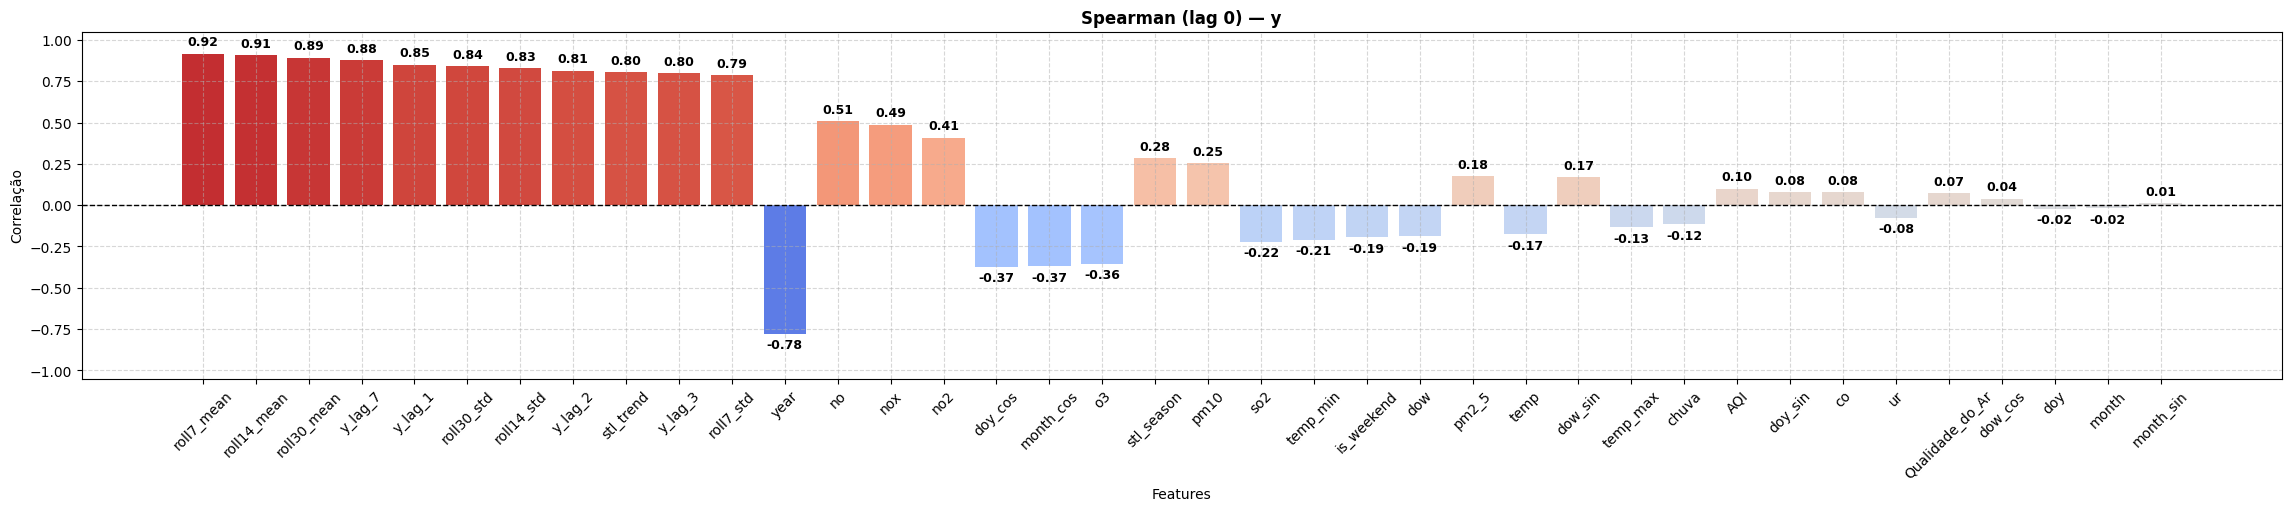

,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,...,y_lag_3,y_lag_7,roll7_mean,roll7_std,roll14_mean,roll14_std,roll30_mean,roll30_std,stl_trend,stl_season
y,-0.116,-0.174,-0.075,0.078,0.51,0.409,0.487,-0.222,-0.355,0.253,...,0.797,0.879,0.917,0.787,0.907,0.829,0.894,0.843,0.803,0.284


In [10]:
df = df_unificado.copy()
df["data_dia"] = pd.to_datetime(df["data_dia"], errors="coerce")
df = df.dropna(subset=["data_dia"]).sort_values("data_dia")

targets = ["y"]
feature_candidates = ['chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'temp_min', 'temp_max', 'AQI', 'Qualidade_do_Ar', 'year', 'month', 'dow', 'doy', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_7', 'roll7_mean', 'roll7_std', 'roll14_mean', 'roll14_std', 'roll30_mean', 'roll30_std', 'stl_trend', 'stl_season']
features = [c for c in feature_candidates if c in df.columns]
if not features:
    raise ValueError("Nenhuma feature candidata encontrada.")

cols_needed = [c for c in targets if c in df.columns] + features
df_valid = df[cols_needed].dropna()

corr_series = {}
for t in targets:
    if t in df_valid.columns:
        s = df_valid[features].corrwith(df_valid[t], method="spearman")
        corr_series[t] = s.sort_values(key=lambda x: x.abs(), ascending=False)

corr_mat = pd.DataFrame(
    {t: df_valid[features].corrwith(df_valid[t], method="spearman") for t in corr_series}
).T[features]

n_tg = len(corr_series)
fig, axes = plt.subplots(1, n_tg, figsize=(max(10, 1.2*len(features))*n_tg/2, 5), constrained_layout=True)
if n_tg == 1:
    axes = [axes]

for ax, (t, s) in zip(axes, corr_series.items()):
    vals = s.values
    idx = s.index
    colors = plt.cm.coolwarm((vals + 1) / 2)
    bars = ax.bar(idx, vals, color=colors)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(f"Spearman (lag 0) — {t}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Features")
    ax.set_ylabel("Correlação")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle="--", alpha=0.5)

    offset = 0.03
    for rect, val in zip(bars, vals):
        x = rect.get_x() + rect.get_width()/2
        y = val + offset if val >= 0 else val - offset
        va = "bottom" if val >= 0 else "top"
        ax.text(x, y, f"{val:.2f}", ha="center", va=va, fontsize=9, fontweight="bold")

plt.show()

display(corr_mat.round(3))


#### Correlação (Spearman, lag 0)

- **Tráfego (NO, NOx, NO₂):** maior associação **positiva**  
  - D+1: NO **0,30**, NOx **0,29**, NO₂ **0,24**  
  - D+7: NO **0,36**, NOx **0,34**, NO₂ **0,27**
- **Ozônio (O₃):** associação **negativa** (D+1 **−0,22**; D+7 **−0,26**).
- **Temperatura:** **negativa** (D+1 **−0,18**; D+7 **−0,20**).
- **Material particulado:** **pequena positiva** (PM₁₀ ~**0,15**; PM₂.₅ ~**0,10**).
- **Chuva/UR/CO/AQI/SO₂:** efeitos **fracos** (|ρ| ≤ ~0,08; AQI ≈ 0).

> Leitura: níveis mais altos de **NO/NOx/NO₂** no dia tendem a acompanhar **mais internações**; **O₃** e **temperatura** mostram relação inversa. As magnitudes são **moderadas**, sugerindo influência adicional de calendário e persistência da série.


#### Resultados

**D+1 (internacoes_d1)**
- **O₃ (MM150, k=0)**: série **fora de fase** com o alvo → relação **negativa**, consistente com ρ≈**−0,50**.  
- **NO / NOx (MM60, k=3)**: **co-movimento positivo** com atraso curto (~**3 dias**), força **moderada** (ρ≈**0,45** e **0,36**).

**D+7 (internacoes_d7)**
- **O₃ (MM150, k=0)**: padrão negativo semelhante ao D+1 (ρ≈**−0,49**).  
- **NO / NOx (MM30, k=0)**: **co-movimento contemporâneo**, também **moderado** (ρ≈**0,44** e **0,36**).

**Notas**
- Padrões **não são perfeitos** (períodos de desacoplamento), mas a **tendência geral** se mantém: **NO/NOx  ↔ internações **; **O₃  ↔ internações **.  
- Interpretar como **associações**, não causalidade; em modelos, controlar **calendário** e **clima** e checar **colinearidade** NOx × O₃.


# Principais resultados

**Sinais consistentes**
- **NO/NOx/NO₂**: **correlação positiva** com as internações (moderada).  
- **O₃**: **correlação negativa** (fora de fase com o alvo).  
- **PM₁₀**: positiva **fraca**; **PM₂.₅** fraca/instável.  
- **Temperatura**: efeito **negativo** moderado; **chuva/UR** fracos.

**Defasagens e janelas mais informativas**
- **D+1**: picos de associação em ~**5–6 dias** (NO/NOx/NO₂ positivos, O₃ negativo).  
  - Destaques: **NO_MM60.shift(3)** (ρ≈**0,45**), **NOX_MM60.shift(3)** (ρ≈**0,36**), **O3_MM150** (ρ≈**−0,50**).
- **D+7**: maior força em **lag 0** (ecos semanais ~7/13).  
  - Destaques: **NO_MM30** (ρ≈**0,44**), **NOX_MM30** (ρ≈**0,36**), **O3_MM150** (ρ≈**−0,49**).
- **Médias móveis** (ex.: **MM7**) tendem a superar o valor pontual (efeito acumulado).

**Estabilidade temporal**
- Correlação rolante (365d): **NO/NO₂** medianas ~**0,20–0,23**; **O₃** ~**−0,12 a −0,15**; variação ao longo dos anos (p10–p90 amplos).

**Estudo de eventos (MM7 top 10%)**
- Após picos de **NO/NO₂**: **pequeno aumento** de internações nos dias seguintes.  
- Após picos de **O₃**: **queda** de internações no curto prazo.  
- Efeitos médios são **modestos** (~±1 internação), mas **consistentes** com as correlações.

**Implicação para modelagem**
- Features candidatas fortes:  
  - **D+1** → `NO_MM60.shift(3)`, `NOX_MM60.shift(3)`, `O3_MM150` (sinais +, +, −).  
  - **D+7** → `NO_MM30`, `NOX_MM30`, `O3_MM150` (sinais +, +, −).  
- Incluir **calendário** (dia-da-semana, mês) e **clima** (temp/UR) como controles e checar **colinearidade** (NOx × O₃).
